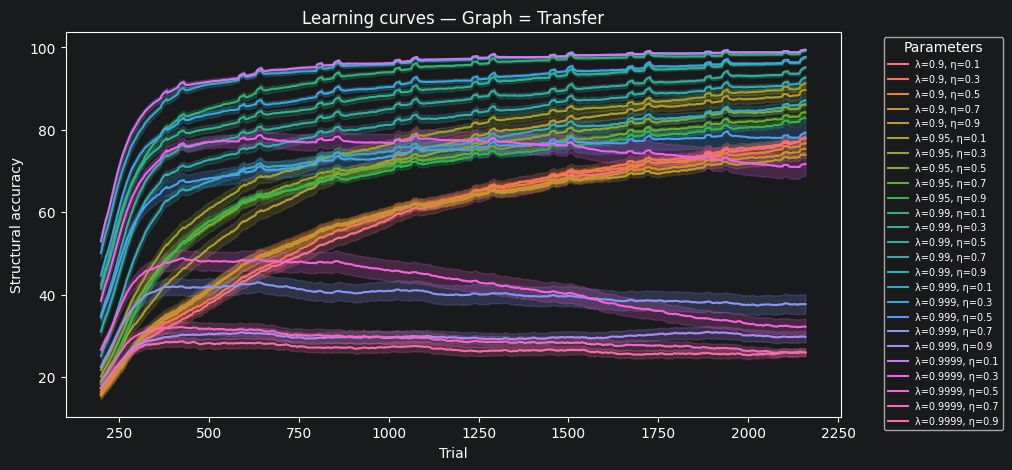

In [9]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from tem import plot
import pingouin as pg

root_dir = Path("~/PycharmProjects/torch_tem").expanduser()
version = "v5"
base_dir = root_dir / "tem_simulation" / "operators" / version
sim_dir = base_dir / "simulation"

# read the results of grid search
df_curves, df_peaks = plot.load_grid_results(sim_dir / "study-19")

# save
fig_dir = base_dir / "figs" / "study-19"
fig_dir.mkdir(exist_ok=True, parents=True)

# learning curves
ax = plot.plot_learning_curves(df_curves, graph="Transfer")
ax.get_figure().savefig(fig_dir / "grid_learning_curves_transfer.pdf", bbox_inches="tight")

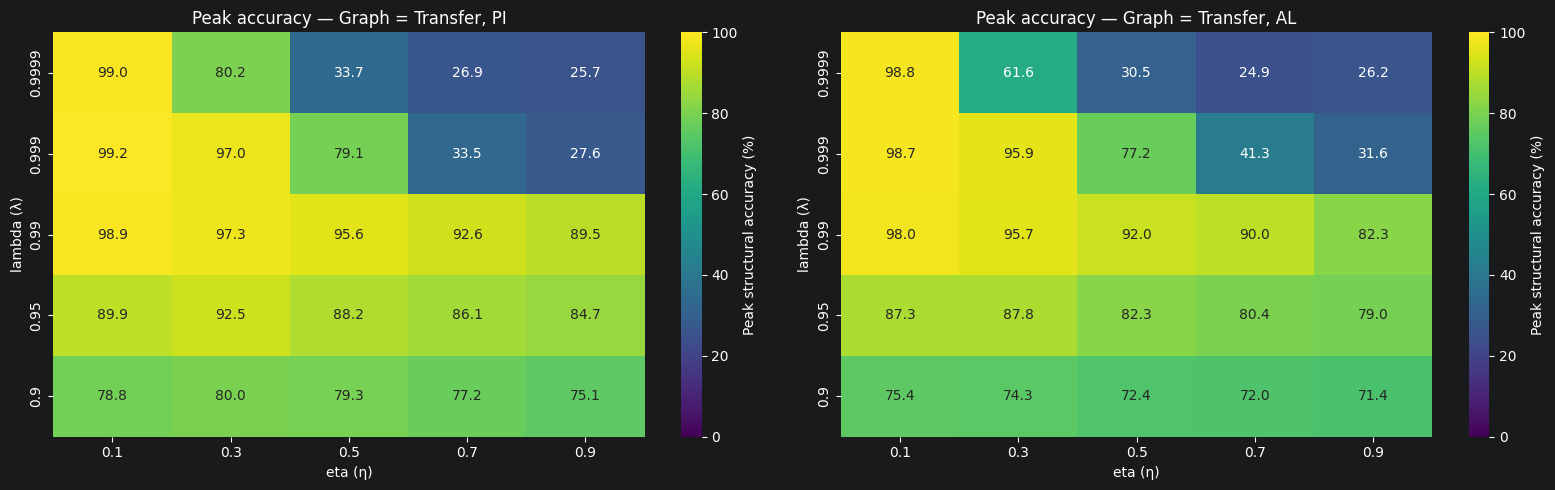

In [10]:
# heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot.plot_param_heatmap(df_peaks, graph="Transfer", condition="PI", ax=axes[0])
plot.plot_param_heatmap(df_peaks, graph="Transfer", condition="AL", ax=axes[1])
plt.tight_layout()
fig.savefig(fig_dir / "grid_heatmap_transfer.pdf", bbox_inches="tight")

In [22]:
# find the curve corresponding to the optimal parameter combination
best_curves = df_curves.filter(
    (pl.col("lambda_val") == 0.99) &
    (pl.col("eta_val") == 0.1) &
    (pl.col("Graph") == "Transfer")
)

# Calculate the peak accuracy for each subject (based on the last 20% of trials).
max_trial = best_curves["Trial"].max()
trial_min = int(max_trial * 0.8)

m = (
    best_curves
    .filter(pl.col("Trial") >= trial_min)
    .group_by("subject", "condition")
    .agg(pl.col("value").mean().alias("peak_accuracy"))
    .sort("subject", "condition")
)

al = m.filter(pl.col("condition") == "AL")["peak_accuracy"].to_numpy()
pi = m.filter(pl.col("condition") == "PI")["peak_accuracy"].to_numpy()

print(f"AL n={len(al)}, PI n={len(pi)}")
print(pg.ttest(al, pi))

AL n=5, PI n=5
               T  dof alternative     p_val           CI95   cohen_d  \
T_test -1.414933    8   two-sided  0.194812  [-2.87, 0.69]  0.894882   

           power   BF10  
T_test  0.239194  0.872  


In [23]:
import polars as pl
from pathlib import Path

root_dir = Path("~/PycharmProjects/torch_tem").expanduser()
raw = pl.read_csv(root_dir / "v5/design/sub-501/sub-501_task-learning_design.csv")

# 只看graph_1
graph1 = raw.filter(pl.col("graph") == "graph_1")
trials_g1 = graph1.filter(
    ~(
        pl.col("trial_type").str.starts_with("practice")
        | pl.col("trial_type").str.contains("instruction")
        | pl.col("trial_type").str.contains("feedback")
    )
)
print("graph_1 total trials:", trials_g1.shape[0])
print("boundary rows (167-169):")
print(trials_g1[166:170][["trial_type", "block"]])

graph_1 total trials: 216
boundary rows (167-169):
shape: (4, 2)
┌─────────────┬───────┐
│ trial_type  ┆ block │
│ ---         ┆ ---   │
│ str         ┆ i64   │
╞═════════════╪═══════╡
│ prediction  ┆ 1     │
│ prediction  ┆ 1     │
│ integration ┆ 2     │
│ integration ┆ 2     │
└─────────────┴───────┘
